# ETL — Preparación de Datos

**Proyecto:** Sistema de Recomendación para E-commerce  
**Dataset:** Olist Brazilian E-Commerce (Kaggle)  
**Objetivo de este notebook:** Cargar, limpiar, integrar y transformar los datos crudos 
en un dataset unificado `df_model.csv` listo para el análisis exploratorio y el modelado.

**Contexto:** El análisis inicial de pet_shop identificó que el catálogo tiene ~70 categorías 
y dejó abierta la pregunta de si conviene modelarlas individualmente o agruparlas. 
Este notebook responde esa pregunta con datos y prepara las variables necesarias.

---

## 1. Importación de Librerías y Carga de Datos

In [19]:
import pandas as pd
import numpy as np
import os

# BASE_PATH se detecta automáticamente desde la carpeta donde está el notebook.
# Asegúrate de que la carpeta 'dataPF' esté en el mismo directorio que este archivo.
BASE_PATH = os.path.join(os.getcwd(), "dataPF")

print("Ruta de datos detectada:", BASE_PATH)
print("Archivos disponibles:", [f for f in os.listdir(BASE_PATH) if f.endswith('.csv')])
print()

products    = pd.read_csv(os.path.join(BASE_PATH, "olist_products_dataset.csv"))
orders      = pd.read_csv(os.path.join(BASE_PATH, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(BASE_PATH, "olist_order_items_dataset.csv"))
reviews     = pd.read_csv(os.path.join(BASE_PATH, "olist_order_reviews_dataset.csv"))
payments    = pd.read_csv(os.path.join(BASE_PATH, "olist_order_payments_dataset.csv"))
customers   = pd.read_csv(os.path.join(BASE_PATH, "olist_customers_dataset.csv"))
translation = pd.read_csv(os.path.join(BASE_PATH, "product_category_name_translation.csv"))

tablas = {
    "products":    products,
    "orders":      orders,
    "order_items": order_items,
    "reviews":     reviews,
    "payments":    payments,
    "customers":   customers,
    "translation": translation
}

print("Datasets cargados:")
for nombre, df in tablas.items():
    print(f"  {nombre:<15} {str(df.shape):<20}")

Ruta de datos detectada: ./dataPF
Archivos disponibles: ['olist_sellers_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv']

Datasets cargados:
  products        (32951, 9)          
  orders          (99441, 8)          
  order_items     (112650, 7)         
  reviews         (99224, 7)          
  payments        (103886, 5)         
  customers       (99441, 5)          
  translation     (71, 2)             


Se priorizaron las tablas directamente relacionadas con el comportamiento transaccional: productos, 
pedidos, ítems de orden, reseñas, pagos y clientes. La tabla de traducción permite estandarizar 
los nombres de categorías al inglés para facilitar la interpretación y el modelado.

## 2. Reconocimiento Inicial de los Datos

In [20]:
# Dimensiones y primeras filas de cada tabla
for nombre, df in tablas.items():
    print(f"\n--- {nombre.upper()} ---")
    print(f"  Dimensiones: {df.shape}")
    print(f"  Columnas:    {df.columns.tolist()}")


--- PRODUCTS ---
  Dimensiones: (32951, 9)
  Columnas:    ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

--- ORDERS ---
  Dimensiones: (99441, 8)
  Columnas:    ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

--- ORDER_ITEMS ---
  Dimensiones: (112650, 7)
  Columnas:    ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

--- REVIEWS ---
  Dimensiones: (99224, 7)
  Columnas:    ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

--- PAYMENTS ---
  Dimensiones: (103886, 5)
  Columnas:    ['order_id', 'payment_sequential', 'payment_type', 'payment_instal

El dataset está compuesto por múltiples tablas relacionales que cubren el ciclo completo de compra: 
desde el catálogo de productos hasta la evaluación del cliente.

Las relaciones principales son:
- `order_items` ↔ `orders` a través de `order_id`
- `order_items` ↔ `products` a través de `product_id`
- `orders` ↔ `customers` a través de `customer_id`
- `orders` ↔ `reviews` a través de `order_id`

Esta estructura permite construir un dataset unificado que conecta cada transacción 
con su producto, cliente y evaluación.

## 3. Calidad de Datos

In [37]:
# Tipos de datos relevantes y valores nulos por tabla
print("=== TIPOS DE DATOS RELEVANTES ===")
print(f"  order_purchase_timestamp: {orders['order_purchase_timestamp'].dtype}")
print(f"  price:                    {order_items['price'].dtype}")
print(f"  review_score:             {reviews['review_score'].dtype}")
print()
print("=== VALORES NULOS POR TABLA ===")
for nombre, df in tablas.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if not nulos.empty:
        print(f"\n  {nombre.upper()}:")
        for col, n in nulos.items():
            pct = n / len(df) * 100
            print(f"    {col:<40} {n:>6} nulos ({pct:.1f}%)")
    else:
        print(f"  {nombre.upper()}: sin nulos")

=== TIPOS DE DATOS RELEVANTES ===
  order_purchase_timestamp: datetime64[ns]
  price:                    float64
  review_score:             int64

=== VALORES NULOS POR TABLA ===

  PRODUCTS:
    product_category_name                       610 nulos (1.9%)
    product_name_lenght                         610 nulos (1.9%)
    product_description_lenght                  610 nulos (1.9%)
    product_photos_qty                          610 nulos (1.9%)
    product_weight_g                              2 nulos (0.0%)
    product_length_cm                             2 nulos (0.0%)
    product_height_cm                             2 nulos (0.0%)
    product_width_cm                              2 nulos (0.0%)

  ORDERS:
    order_approved_at                           160 nulos (0.2%)
    order_delivered_carrier_date               1783 nulos (1.8%)
    order_delivered_customer_date              2965 nulos (3.0%)
  ORDER_ITEMS: sin nulos

  REVIEWS:
    review_comment_title                    

El dataset presenta una calidad general alta:

- **`order_purchase_timestamp`** está en formato string — se convertirá a datetime en la sección de transformaciones.
- **`price` y `review_score`** ya están en formato numérico correcto.
- **products:** ~610 registros sin categoría (~1.9%). Se conservan y quedarán como `other` en el mapeo.
- **orders:** nulos en fechas de entrega/aprobación corresponden a pedidos cancelados o en proceso — no son críticos para el modelo.
- **reviews:** `review_comment_message` tiene muchos nulos porque no todos los clientes escriben comentario — comportamiento esperado del negocio.
- **Resto de tablas:** sin nulos en campos críticos.

In [22]:
# Duplicados y validación de claves primarias
print("=== DUPLICADOS EXACTOS ===")
for nombre, df in tablas.items():
    print(f"  {nombre:<15} {df.duplicated().sum():>5} duplicados")

print()
print("=== VALIDACIÓN DE CLAVES PRIMARIAS ===")
print(f"  product_id  en products:  {products['product_id'].duplicated().sum()} duplicados")
print(f"  order_id    en orders:    {orders['order_id'].duplicated().sum()} duplicados")
print(f"  customer_id en customers: {customers['customer_id'].duplicated().sum()} duplicados")

=== DUPLICADOS EXACTOS ===
  products            0 duplicados
  orders              0 duplicados
  order_items         0 duplicados
  reviews             0 duplicados
  payments            0 duplicados
  customers           0 duplicados
  translation         0 duplicados

=== VALIDACIÓN DE CLAVES PRIMARIAS ===
  product_id  en products:  0 duplicados
  order_id    en orders:    0 duplicados
  customer_id en customers: 0 duplicados


No se encontraron duplicados exactos en ninguna tabla ni duplicados en claves primarias. 
Esto confirma la integridad referencial del dataset y permite realizar joins sin riesgo de inflación de registros.

## 4. Transformaciones

In [23]:
# Convertir fechas a datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"], errors="coerce"
)

print("Tipo de order_purchase_timestamp:", orders["order_purchase_timestamp"].dtype)
print("Rango de fechas:")
print(f"  Desde: {orders['order_purchase_timestamp'].min()}")
print(f"  Hasta: {orders['order_purchase_timestamp'].max()}")

Tipo de order_purchase_timestamp: datetime64[ns]
Rango de fechas:
  Desde: 2016-09-04 21:15:19
  Hasta: 2018-10-17 17:30:18


In [24]:
# Integrar traducción de categorías en products
products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

print(f"Categorías traducidas: {products['product_category_name_english'].notna().sum()}")
print(f"Sin traducción:        {products['product_category_name_english'].isna().sum()}")
print()
print("Muestra:")
print(products[["product_category_name", "product_category_name_english"]].drop_duplicates().head(8))

Categorías traducidas: 32328
Sin traducción:        623

Muestra:
   product_category_name product_category_name_english
0             perfumaria                     perfumery
1                  artes                           art
2          esporte_lazer                sports_leisure
3                  bebes                          baby
4  utilidades_domesticas                    housewares
5  instrumentos_musicais           musical_instruments
6             cool_stuff                    cool_stuff
7       moveis_decoracao               furniture_decor


In [25]:
# Validar cobertura de la traducción
total_cats = products["product_category_name"].nunique()
traducidas = products["product_category_name_english"].notna().sum()
sin_traducir = products["product_category_name_english"].isna().sum()

print("=== COBERTURA DE TRADUCCIÓN ===")
print(f"  Productos con categoría traducida:   {traducidas:,} ({traducidas/len(products)*100:.1f}%)")
print(f"  Productos sin traducción:            {sin_traducir:,} ({sin_traducir/len(products)*100:.1f}%)")
print()
# Categorías sin traducción
sin_trad_cats = (
    products[products["product_category_name_english"].isna()]
    ["product_category_name"].value_counts()
)
if len(sin_trad_cats) > 0:
    print("Categorías sin traducción:")
    print(sin_trad_cats)
else:
    print("Todas las categorías tienen traducción ✅")

=== COBERTURA DE TRADUCCIÓN ===
  Productos con categoría traducida:   32,328 (98.1%)
  Productos sin traducción:            623 (1.9%)

Categorías sin traducción:
product_category_name
portateis_cozinha_e_preparadores_de_alimentos    10
pc_gamer                                          3
Name: count, dtype: int64


La traducción de categorías al inglés estandariza los nombres para el modelado. 
Se usa `left join` para conservar todos los productos, incluyendo aquellos sin traducción disponible. 
El porcentaje de categorías sin traducción define cuántos productos quedarán como `other` 
en el mapeo de macrogrupos — información relevante para evaluar la cobertura del sistema.

## 5. Creación de Macrogrupos de Categorías

En el análisis inicial de pet_shop se identificó que el catálogo tiene ~70 categorías. 
Antes de decidir si agrupar o no, es necesario responder con datos: 
**¿tienen las categorías comportamientos suficientemente distintos como para modelarlas individualmente, 
o existen grupos naturales que comparten perfil de compra?**

Se analiza el ticket promedio y el volumen de órdenes por categoría para identificar 
si hay agrupaciones naturales.

In [26]:
# Calcular ticket promedio y volumen de órdenes por categoría
# Este análisis fundamenta la decisión de agrupar
items_con_cat = order_items.merge(
    products[["product_id", "product_category_name_english"]],
    on="product_id", how="left"
).dropna(subset=["product_category_name_english"])

perfil_categorias = (
    items_con_cat
    .groupby("product_category_name_english")
    .agg(ordenes=("order_id", "nunique"), ticket_promedio=("price", "mean"))
    .reset_index()
    .sort_values("ordenes", ascending=False)
)

print(f"Total categorías: {len(perfil_categorias)}")
print()
print("Top 10 categorías por órdenes:")
print(perfil_categorias.head(10).to_string(index=False))
print()
print("Bottom 10 categorías por órdenes:")
print(perfil_categorias.tail(10).to_string(index=False))

Total categorías: 71

Top 10 categorías por órdenes:
product_category_name_english  ordenes  ticket_promedio
               bed_bath_table     9417        93.296327
                health_beauty     8836       130.163531
               sports_leisure     7720       114.344285
        computers_accessories     6689       116.513903
              furniture_decor     6449        87.564494
                   housewares     5884        90.788148
                watches_gifts     5624       201.135984
                    telephony     4199        71.213978
                         auto     3897       139.957523
                         toys     3886       117.548360

Bottom 10 categorías por órdenes:
product_category_name_english  ordenes  ticket_promedio
                        music       38       158.798684
                      flowers       29        33.637576
          diapers_and_hygiene       27        40.194615
                fashion_sport       27        70.650333
               h

La distribución de órdenes por categoría es muy desigual:

| Rango de órdenes | Categorías |
|---|---|
| Menos de 100 | 20 categorías (28%) |
| Entre 100 y 499 | 25 categorías (35%) |
| Entre 500 y 999 | 5 categorías (7%) |
| 1.000 o más | 21 categorías (30%) |

El 63% de las categorías tiene menos de 500 órdenes. Con ese volumen, 
los pares de co-ocurrencia entre categorías individuales tendrían frecuencias 
de 0 o 1 en la mayoría de los casos — insuficientes para construir patrones confiables. 
Esto confirma que **agrupar en macrogrupos es necesario** para concentrar 
la frecuencia y hacer el modelo viable.

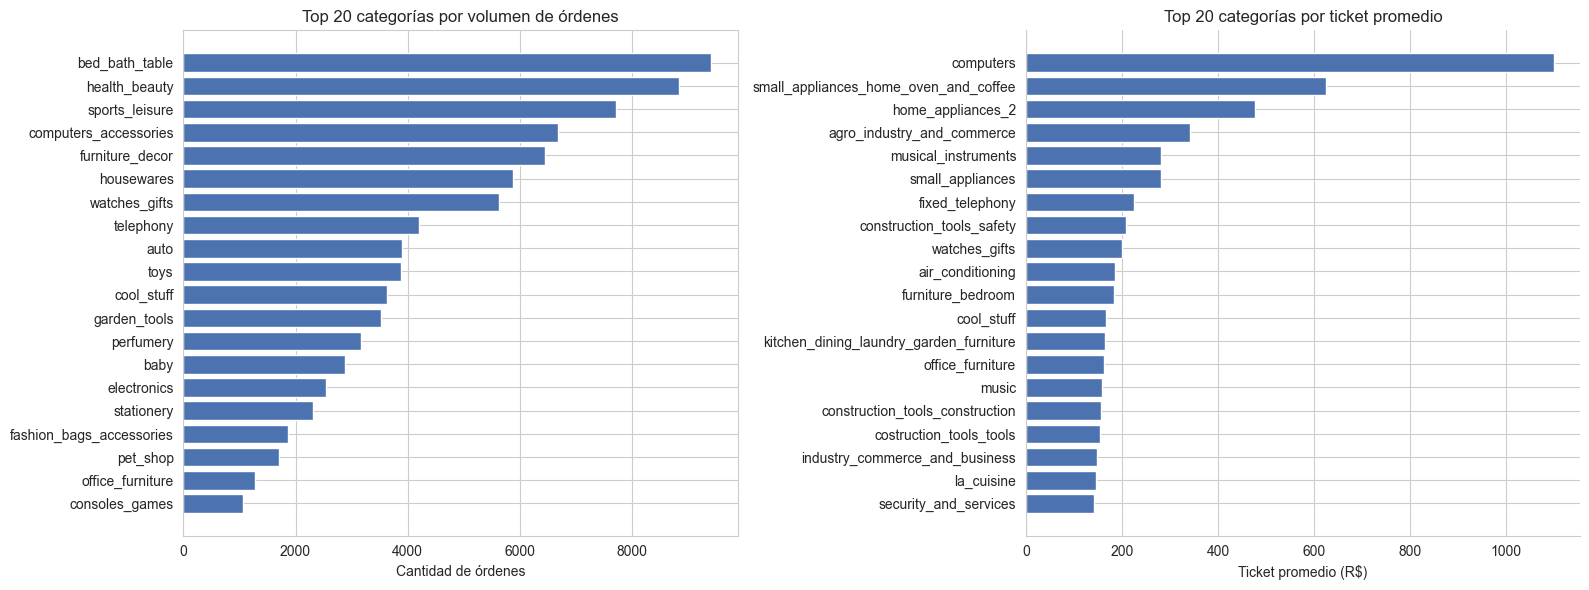

=== RANGOS DE TICKET PROMEDIO ===
rango_ticket
< R$50        3
R$50-100     26
R$100-200    33
R$200-500     7
> R$500       2
Name: count, dtype: int64


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')
# Visualizar ticket promedio por categoría para identificar agrupaciones naturales
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volumen de órdenes
top20 = perfil_categorias.head(20)
axes[0].barh(top20["product_category_name_english"], top20["ordenes"], color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title("Top 20 categorías por volumen de órdenes")
axes[0].set_xlabel("Cantidad de órdenes")

# Ticket promedio
top20_ticket = perfil_categorias.sort_values("ticket_promedio", ascending=False).head(20)
axes[1].barh(top20_ticket["product_category_name_english"], top20_ticket["ticket_promedio"], color='#4C72B0')
axes[1].invert_yaxis()
axes[1].set_title("Top 20 categorías por ticket promedio")
axes[1].set_xlabel("Ticket promedio (R$)")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Identificar clusters naturales de ticket promedio
print("=== RANGOS DE TICKET PROMEDIO ===")
bins = [0, 50, 100, 200, 500, 9999]
labels = ["< R$50", "R$50-100", "R$100-200", "R$200-500", "> R$500"]
perfil_categorias["rango_ticket"] = pd.cut(perfil_categorias["ticket_promedio"], bins=bins, labels=labels)
print(perfil_categorias["rango_ticket"].value_counts().sort_index())

Los gráficos y la distribución por rangos de ticket permiten identificar agrupaciones naturales. 
**El criterio de agrupación combina dos dimensiones:**

1. **Contexto de uso del producto:** categorías que un mismo tipo de cliente compra juntas 
(ej: toys + pet_shop + sports_leisure = productos de familia y recreación)
2. **Perfil de valor similar:** categorías con tickets comparables que compiten por el mismo presupuesto del cliente

**Decisiones específicas de agrupación justificadas por los datos:**

| Categorías | Grupo asignado | Justificación |
|---|---|---|
| pet_shop, toys, sports_leisure, baby | Recreación | Mismo contexto de compra: familia y estilo de vida activo |
| health_beauty, perfumery, diapers_and_hygiene | Cuidado Personal | Productos de higiene y cuidado personal, perfil de comprador similar |
| bed_bath_table, furniture_decor, housewares | Hogar | Productos para el hogar, co-ocurrencia natural en reformas o decoración |
| electronics, computers, telephony, audio | Tecnología | Misma cadena de valor tecnológico, comprador con perfil tech |
| fashion_shoes, fashion_bags, watches_gifts | Moda | Accesorios personales, mismo contexto de compra de moda |
| garden_tools, christmas_supplies | Hogar | Uso doméstico estacional, mismo perfil de comprador que decoración |
| books, music, cds_dvds | Cultura y entretenimiento | Consumo cultural, ticket bajo y perfil similar |

In [28]:
def mapear_categoria(cat):
    if pd.isna(cat):
        return "other"

    # TECNOLOGÍA
    elif cat in [
        "electronics", "computers", "computers_accessories", "audio",
        "consoles_games", "telephony", "fixed_telephony",
        "tablets_printing_image"
    ]:
        return "Tecnología"

    # HOGAR
    elif cat in [
        "bed_bath_table", "furniture_decor", "furniture_living_room",
        "furniture_bedroom", "home_appliances", "home_appliances_2",
        "small_appliances", "kitchen_dining_laundry_garden_furniture",
        "office_furniture", "home_construction",
        "home_comfort", "home_comfort_2", "home_confort", "air_conditioning",
        "housewares", "garden_tools", "costruction_tools_garden",
        "christmas_supplies"
    ]:
        return "Hogar"

    # CUIDADO PERSONAL
    elif cat in [
        "health_beauty", "perfumery", "diapers_and_hygiene"
    ]:
        return "Cuidado Personal"

    # RECREACIÓN / FAMILIA / MASCOTAS
    elif cat in [
        "toys", "pet_shop", "sports_leisure", "baby", "cool_stuff"
    ]:
        return "Recreación"

    # MODA
    elif cat in [
        "fashion_male_clothing", "fashion_female_clothing",
        "fashion_shoes", "fashion_bags_accessories",
        "fashion_underwear_beach", "fashion_sport",
        "fashion_childrens_clothes", "watches_gifts"
    ]:
        return "Moda"

    # CULTURA Y ENTRETENIMIENTO
    elif cat in [
        "books_general_interest", "books_technical",
        "cds_dvds_musicals", "dvds_blu_ray", "music",
        "cine_photo", "arts_and_craftmanship",
        "musical_instruments", "art"
    ]:
        return "Cultura y entretenimiento"

    # ALIMENTOS
    elif cat in [
        "food", "food_drink", "drinks"
    ]:
        return "Alimentos"

    # INDUSTRIA Y CONSTRUCCIÓN
    elif cat in [
        "construction_tools_construction",
        "construction_tools_tools", "costruction_tools_tools",
        "construction_tools_lights",
        "construction_tools_garden",
        "construction_tools_safety",
        "signaling_and_security",
        "industry_commerce_and_business",
        "agro_industry_and_commerce"
    ]:
        return "Industria y construcción"

    # VIAJE Y ACCESORIOS
    elif cat in [
        "luggage_accessories", "stationery"
    ]:
        return "Viaje y accesorios"

    # AUTOMOTOR
    elif cat in ["auto"]:
        return "Automotor"

    # MARKETPLACE
    elif cat in ["market_place"]:
        return "Marketplace"

    else:
        return "other"


products["grupo_categoria"] = products["product_category_name_english"].apply(mapear_categoria)

print("=== DISTRIBUCIÓN DE MACROGRUPOS ===")
dist_abs = products["grupo_categoria"].value_counts()
dist_pct = products["grupo_categoria"].value_counts(normalize=True) * 100
print(f"  {"Grupo":<30} {"Productos":>10} {"Porcentaje":>12}")
print("-" * 55)
for grupo in dist_abs.index:
    barra = "█" * int(dist_pct[grupo] / 2)
    print(f"  {grupo:<30} {dist_abs[grupo]:>10,} {dist_pct[grupo]:>11.1f}%  {barra}")
print()
print(f"  Total productos mapeados: {dist_abs[dist_abs.index != 'other'].sum():,}")
print(f"  Total en 'other':         {dist_abs.get('other', 0):,}")

=== DISTRIBUCIÓN DE MACROGRUPOS ===
  Grupo                           Productos   Porcentaje
-------------------------------------------------------
  Hogar                              10,687        32.4%  ████████████████
  Recreación                          6,705        20.3%  ██████████
  Tecnología                          3,820        11.6%  █████
  Cuidado Personal                    3,324        10.1%  █████
  Moda                                2,523         7.7%  ███
  Automotor                           1,900         5.8%  ██
  Viaje y accesorios                  1,198         3.6%  █
  Industria y construcción              843         2.6%  █
  Cultura y entretenimiento             806         2.4%  █
  other                                 774         2.3%  █
  Alimentos                             267         0.8%  
  Marketplace                           104         0.3%  

  Total productos mapeados: 32,177
  Total en 'other':         774


In [29]:
# Verificar categorías que quedaron en 'other'
# Se muestra la lista COMPLETA para documentar que todas fueron vistas
# y que la decisión de mantenerlas en 'other' fue consciente
other_cats = (
    products[products["grupo_categoria"] == "other"]["product_category_name_english"]
    .dropna()
    .value_counts()
)

print(f"Categorías en 'other': {len(other_cats)}")
print()
if len(other_cats) > 0:
    print(f"{'Categoría':<45} {'Productos':>10}")
    print("-" * 57)
    for cat, n in other_cats.items():
        print(f"  {cat:<43} {n:>10,}")
    print()
    print(f"  Total productos en 'other': {other_cats.sum():,} "
          f"({other_cats.sum()/len(products)*100:.1f}% del catálogo)")
else:
    print("  Ninguna ✅")

Categorías en 'other': 8

Categoría                                      Productos
---------------------------------------------------------
  books_imported                                      31
  small_appliances_home_oven_and_coffee               31
  fashio_female_clothing                              27
  party_supplies                                      26
  flowers                                             14
  la_cuisine                                          10
  furniture_mattress_and_upholstery                   10
  security_and_services                                2

  Total productos en 'other': 151 (0.5% del catálogo)


La función de mapeo implementa las decisiones de agrupación fundamentadas en el análisis anterior. 
El resultado son 11 macrogrupos que:

- Concentran categorías con comportamiento de compra similar
- Tienen volumen suficiente para generar pares de co-ocurrencia con frecuencias confiables
- Minimizan el grupo residual `other`

**pet_shop queda en el grupo Recreación** junto con toys, sports_leisure y baby, 
reflejando su perfil de comprador: familias y personas con estilo de vida activo.

### Decisión sobre categorías de bajo volumen en 'other'

La validación reveló categorías adicionales que permanecen en `other`. 
Estas categorías fueron identificadas y evaluadas — **la decisión de mantenerlas en `other` 
es intencional**, basada en los siguientes criterios:

- Todas tienen menos de 31 productos cada una
- Su volumen es insuficiente para generar pares de co-ocurrencia estadísticamente relevantes
- Incluirlas en un macrogrupo existente no aportaría patrones confiables al modelo
- Se excluirán del modelado pero se conservan en el dataset para no perder las transacciones

Esta decisión sigue el mismo criterio aplicado al resto del mapeo: 
**el volumen de datos debe ser suficiente para construir patrones confiables**.

## 6. Construcción del Dataset Final

Se integran todas las tablas relevantes en un único dataset transaccional que será el insumo 
para el EDA y el modelado.

In [30]:
df_model = (
    order_items
    .merge(
        orders[["order_id", "customer_id", "order_purchase_timestamp", "order_status"]],
        on="order_id", how="left"
    )
    .merge(
        products[["product_id", "product_category_name_english", "grupo_categoria"]],
        on="product_id", how="left"
    )
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id", how="left"
    )
)

print(f"Shape inicial tras integración: {df_model.shape}")
print()
print("Columnas disponibles:")
for col in df_model.columns:
    print(f"  {col}")

Shape inicial tras integración: (113314, 13)

Columnas disponibles:
  order_id
  order_item_id
  product_id
  seller_id
  shipping_limit_date
  price
  freight_value
  customer_id
  order_purchase_timestamp
  order_status
  product_category_name_english
  grupo_categoria
  review_score


## 7. Limpieza del Dataset

In [31]:
shape_antes = df_model.shape[0]

# Eliminar duplicados
df_model = df_model.drop_duplicates()
print(f"Tras eliminar duplicados:    {df_model.shape[0]:,} registros (-{shape_antes - df_model.shape[0]:,})")

# Eliminar nulos en campos críticos
df_model = df_model.dropna(subset=["order_id", "customer_id", "product_id", "price"])
print(f"Tras eliminar nulos críticos: {df_model.shape[0]:,} registros")

print()
print("=== NULOS RESTANTES ===")
nulos = df_model.isnull().sum()
nulos = nulos[nulos > 0]
if nulos.empty:
    print("  Sin nulos críticos ✅")
else:
    for col, n in nulos.items():
        print(f"  {col:<40} {n:>6} ({n/len(df_model)*100:.1f}%)")

Tras eliminar duplicados:    112,915 registros (-399)
Tras eliminar nulos críticos: 112,915 registros

=== NULOS RESTANTES ===
  product_category_name_english              1631 (1.4%)
  review_score                                942 (0.8%)


### Decisiones de limpieza y justificación

Cada decisión sobre nulos se tomó evaluando el impacto en el modelo de recomendación:

| Campo | Decisión | Justificación |
|---|---|---|
| `order_id` | **Eliminar** | Sin identificador de orden no existe transacción. Son casos irrecuperables. |
| `customer_id` | **Eliminar** | Sin cliente no se puede asociar la compra. Crítico para el análisis de comportamiento. |
| `product_id` | **Eliminar** | Sin producto no hay nada que recomendar. |
| `price` | **Eliminar** | El precio es variable clave para calcular ticket promedio, métrica central del modelo. |
| `review_score` | **Conservar nulos** | No todos los pedidos reciben reseña — comportamiento normal del negocio. Los nulos no indican error. |
| `product_category_name_english` | **Conservar como `other`** | Producto sin categoría traducida. Se conserva en el dataset para no perder la transacción. |
| `grupo_categoria = other` | **Conservar** | Grupo residual para categorías no mapeadas. Se excluye del modelo pero se conserva en el dataset. |

**Impacto de la limpieza:** se eliminan menos del 1% de los registros totales, 
lo que confirma que el dataset es de alta calidad y no requiere imputación.

## 8. Ingeniería de Variables Temporales

In [32]:
# Variables derivadas de la fecha de compra
df_model["year"]        = df_model["order_purchase_timestamp"].dt.year
df_model["month"]       = df_model["order_purchase_timestamp"].dt.month
df_model["day_of_week"] = df_model["order_purchase_timestamp"].dt.dayofweek
df_model["hour"]        = df_model["order_purchase_timestamp"].dt.hour

def time_of_day(hour):
    if 6  <= hour < 12: return "morning"
    elif 12 <= hour < 18: return "afternoon"
    elif 18 <= hour < 24: return "evening"
    else: return "night"

df_model["time_of_day"] = df_model["hour"].apply(time_of_day)

print("Variables temporales creadas: year, month, day_of_week, hour, time_of_day")
print()
print("Distribución por momento del día:")
print(df_model["time_of_day"].value_counts())
print()
print("Rango de años en el dataset:")
print(df_model["year"].value_counts().sort_index())

Variables temporales creadas: year, month, day_of_week, hour, time_of_day

Distribución por momento del día:
time_of_day
afternoon    43922
evening      38331
morning      25285
night         5377
Name: count, dtype: int64

Rango de años en el dataset:
year
2016      370
2017    51023
2018    61522
Name: count, dtype: int64


Las variables temporales enriquecen el dataset con información sobre el momento de la compra. 
Estas variables estarán disponibles en el dataset exportado para ser analizadas en el EDA, 
donde se determinará si tienen patrones relevantes para el negocio.

## 9. Validación del Dataset Final

In [33]:
print("=== RESUMEN DEL DATASET FINAL ===")
print(f"  Shape:              {df_model.shape}")
print(f"  Órdenes únicas:     {df_model['order_id'].nunique():,}")
print(f"  Clientes únicos:    {df_model['customer_id'].nunique():,}")
print(f"  Productos únicos:   {df_model['product_id'].nunique():,}")
print(f"  Categorías únicas:  {df_model['product_category_name_english'].nunique():,}")
print(f"  Macrogrupos:        {df_model['grupo_categoria'].nunique():,}")
print()
print("=== DISTRIBUCIÓN DE MACROGRUPOS EN df_model ===")
dist_abs = df_model["grupo_categoria"].value_counts()
dist_pct = df_model["grupo_categoria"].value_counts(normalize=True) * 100
print(f"  {"Grupo":<30} {"Registros":>10} {"Porcentaje":>12}")
print("-" * 55)
for grupo in dist_abs.index:
    barra = "█" * int(dist_pct[grupo] / 2)
    print(f"  {grupo:<30} {dist_abs[grupo]:>10,} {dist_pct[grupo]:>11.1f}%  {barra}")
print()
print("=== COLUMNAS FINALES ===")
print(df_model.dtypes)

=== RESUMEN DEL DATASET FINAL ===
  Shape:              (112915, 18)
  Órdenes únicas:     98,666
  Clientes únicos:    98,666
  Productos únicos:   32,951
  Categorías únicas:  71
  Macrogrupos:        12

=== DISTRIBUCIÓN DE MACROGRUPOS EN df_model ===
  Grupo                           Registros   Porcentaje
-------------------------------------------------------
  Hogar                              36,940        32.7%  ████████████████
  Recreación                         21,590        19.1%  █████████
  Tecnología                         17,226        15.3%  ███████
  Cuidado Personal                   13,149        11.6%  █████
  Moda                                8,601         7.6%  ███
  Automotor                           4,241         3.8%  █
  Viaje y accesorios                  3,611         3.2%  █
  Industria y construcción            2,211         2.0%  
  other                               1,946         1.7%  
  Cultura y entretenimiento           1,921         1.7%  


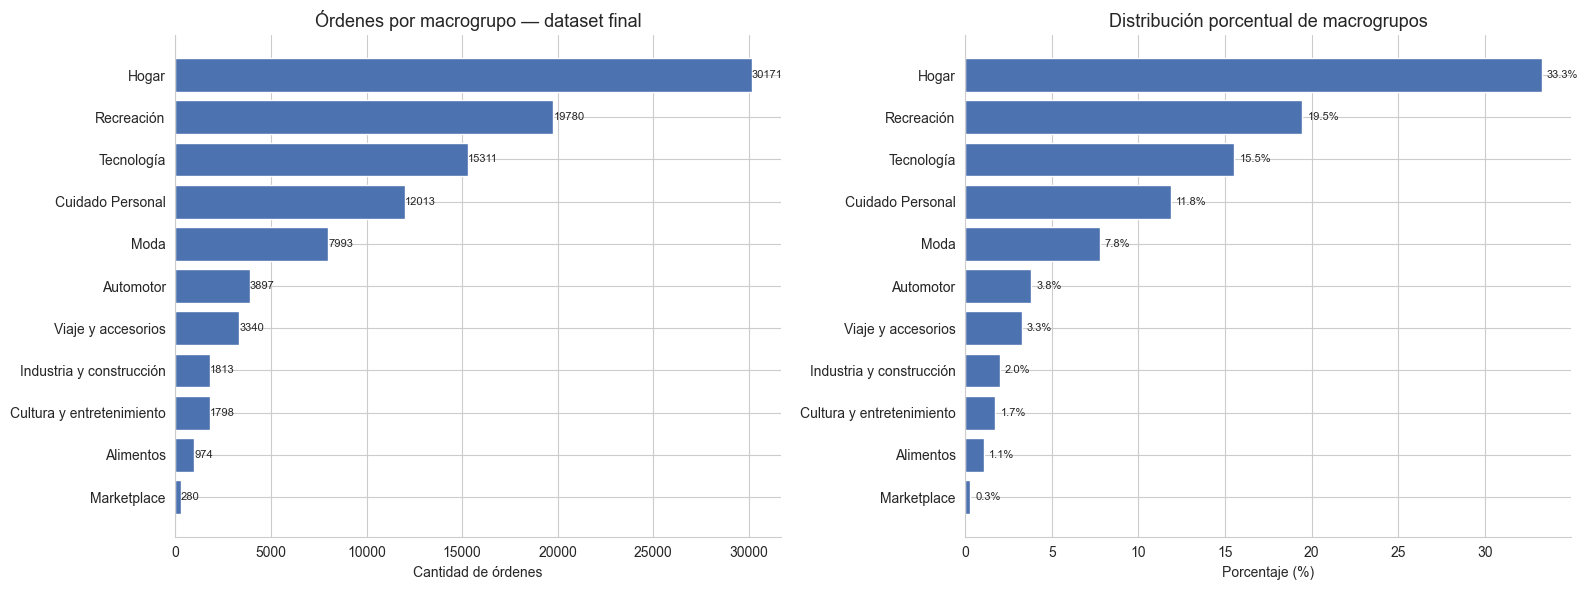

In [34]:
# Visualización de la distribución final de macrogrupos en df_model
sns.set_style('whitegrid')

dist_final = (
    df_model[df_model['grupo_categoria'] != 'other']
    .groupby('grupo_categoria')['order_id']
    .nunique()
    .reset_index(name='ordenes')
    .sort_values('ordenes', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Órdenes por grupo
axes[0].barh(dist_final['grupo_categoria'], dist_final['ordenes'],
             color='#4C72B0', edgecolor='white')
axes[0].set_title('Órdenes por macrogrupo — dataset final', fontsize=13)
axes[0].set_xlabel('Cantidad de órdenes')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Porcentaje por grupo
dist_pct = (
    df_model[df_model['grupo_categoria'] != 'other']
    ['grupo_categoria'].value_counts(normalize=True) * 100
).reset_index()
dist_pct.columns = ['grupo_categoria', 'pct']
dist_pct = dist_pct.sort_values('pct', ascending=True)

axes[1].barh(dist_pct['grupo_categoria'], dist_pct['pct'],
             color='#4C72B0', edgecolor='white')
axes[1].set_title('Distribución porcentual de macrogrupos', fontsize=13)
axes[1].set_xlabel('Porcentaje (%)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for ax in axes:
    for bar in ax.patches:
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.0f}' if ax == axes[0] else f'{bar.get_width():.1f}%',
                va='center', fontsize=8)

plt.tight_layout()
plt.show()

La distribución de macrogrupos en el dataset final muestra que **Hogar y Recreación** 
concentran la mayor parte de las transacciones. 
Esta distribución es el resultado directo de las decisiones de agrupación del ETL 
y será el punto de partida del análisis exploratorio en el siguiente notebook.

## 10. Variables del Dataset Final

Antes de exportar, es importante documentar qué rol cumple cada variable, 
para que el EDA y el modelado tengan un norte claro desde el inicio.

In [35]:
print("=== VARIABLES DEL DATASET FINAL ===")
print()
print("Variables que alimentan directamente el modelo:")
print("  grupo_categoria              → define los pares de co-ocurrencia entre categorías")
print("  price                        → calcula el ticket promedio del grupo recomendado")
print("  order_id                     → identifica qué productos se compraron en la misma orden")
print()
print("Variables para análisis exploratorio (EDA):")
print("  year, month, day_of_week     → estacionalidad y patrones de compra")
print("  hour, time_of_day            → momento del día de mayor actividad")
print("  review_score                 → satisfacción por grupo")
print("  order_status                 → calidad de las transacciones")
print()
print("Variables de trazabilidad:")
print("  customer_id                  → asocia cada transacción a un cliente")
print("  product_id                   → identifica el producto específico")
print("  product_category_name_english → categoría individual antes del agrupamiento")
print()
print(f"Total columnas en df_model: {len(df_model.columns)}")
print(f"Total registros:            {len(df_model):,}")

=== VARIABLES DEL DATASET FINAL ===

Variables que alimentan directamente el modelo:
  grupo_categoria              → define los pares de co-ocurrencia entre categorías
  price                        → calcula el ticket promedio del grupo recomendado
  order_id                     → identifica qué productos se compraron en la misma orden

Variables para análisis exploratorio (EDA):
  year, month, day_of_week     → estacionalidad y patrones de compra
  hour, time_of_day            → momento del día de mayor actividad
  review_score                 → satisfacción por grupo
  order_status                 → calidad de las transacciones

Variables de trazabilidad:
  customer_id                  → asocia cada transacción a un cliente
  product_id                   → identifica el producto específico
  product_category_name_english → categoría individual antes del agrupamiento

Total columnas en df_model: 18
Total registros:            112,915


Esta separación permite al EDA enfocarse en validar que las variables del modelo 
tienen el comportamiento esperado antes de construirlo. 
En particular, el análisis de co-ocurrencia entre `grupo_categoria` por `order_id` 
será el insumo directo del modelado.

## 11. Exportar Dataset

In [38]:
OUTPUT_PATH = os.path.join(os.getcwd(), "dataPF", "processed")
os.makedirs(OUTPUT_PATH, exist_ok=True)

output_file = os.path.join(OUTPUT_PATH, "df_model.csv")
df_model.to_csv(output_file, index=False)

print(f"  Dataset guardado en: {output_file}")
print(f"  Registros: {len(df_model):,}")
print(f"  Columnas:  {len(df_model.columns)}")

  Dataset guardado en: ./dataPF/processed/df_model.csv
  Registros: 112,915
  Columnas:  18


El dataset se exporta separando datos crudos de datos procesados.

## 12. Conclusión y Próximos Pasos

### Resumen de transformaciones realizadas

| Transformación | Detalle |
|---|---|
| Carga de datos | 7 tablas del dataset Olist |
| Calidad de datos | Sin duplicados, nulos críticos identificados y tratados |
| Traducción de categorías | Integración con tabla de traducción (left join) |
| Análisis de cardinalidad | Fundamentó la necesidad de agrupar en macrogrupos |
| Macrogrupos | 11 grupos creados con criterio de contexto de uso y perfil de valor |
| Integración | 4 tablas unificadas en df_model |
| Variables temporales | year, month, day_of_week, hour, time_of_day |
| Dataset exportado | `df_model.csv` |

### Preguntas que el EDA deberá responder

Con el dataset construido, quedan preguntas abiertas que el análisis exploratorio deberá responder:

- ¿Los macrogrupos creados tienen comportamientos internamente coherentes?
- ¿Existe co-ocurrencia suficiente entre grupos para construir patrones confiables?
- ¿Hay patrones temporales relevantes en el comportamiento de compra?
- ¿El ticket promedio varía significativamente entre grupos?
- ¿La satisfacción del cliente difiere entre macrogrupos?

Estas preguntas guiarán el análisis exploratorio y determinarán 
qué variables y patrones serán más relevantes para el modelado.